<a href="https://colab.research.google.com/github/FivaKit/practice/blob/main/%5Bhw%5Dgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [ ]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

In [ ]:
import os
from google.colab import userdata

# Set the environment variables for Kaggle API
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
!kaggle datasets download -d tommykamaz/faces-dataset-small -p /content/

Dataset URL: https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.98G/3.99G [01:11<00:00, 38.6MB/s]
100% 3.99G/3.99G [01:11<00:00, 59.6MB/s]


In [ ]:
import zipfile
import os

zip_path = "/content/faces-dataset-small.zip"
extract_dir = "/content/faces-dataset-small"

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction successful!")
except zipfile.BadZipFile as e:
    print(f"Error: {e}")

Extraction successful!


## Часть 1. Подготовка данных (0.5 балла)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [ ]:
DIR = './faces-dataset-small/'
def get_dataloader(image_size, batch_size):

  ds = ImageFolder(DIR, transform=tt.Compose([
      tt.Resize(image_size),
      tt.ToTensor(),
      tt.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
      ])
  )

  dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2)

  """
  Builds dataloader for training data.
  Use tt.Compose and tt.Resize for transformations
  :param image_size: height and wdith of the image
  :param batch_size: batch_size of the dataloader
  :returns: DataLoader object
  """
  return dl

In [ ]:
image_size = 128

train_dataloader = get_dataloader(image_size=image_size, batch_size=128)
#TODO: build dataloader and transfer it to device

In [ ]:
len(train_dataloader)

25

In [ ]:
ex = next(iter(train_dataloader))[0]


In [ ]:
ex.shape[0]

128

## Часть 2. Построение и обучение модели (2 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [ ]:
from torch.nn.modules.activation import Sigmoid
from torch.nn.modules.flatten import Flatten
from torch.nn.modules.conv import Conv2d, ConvTranspose2d
discriminator = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=4, stride=2, padding=1, bias=False), #64
    nn.LeakyReLU(0.2, inplace=True),
    nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1, bias=False), #32
    nn.BatchNorm2d(32),
    nn.LeakyReLU(0.2, inplace=True),
    # nn.Conv2d(32, 32, kernel_size=4, stride=2, padding=1), #16
    nn.Flatten(),
    nn.Linear(32*32*32, 1),
    nn.Sigmoid()
)

In [ ]:
from torch.nn.modules import Unflatten
from torch.nn.modules.linear import Linear

generator = nn.Sequential(
    nn.Linear(64, 128*4*4),
    nn.BatchNorm1d(128*4*4),
    nn.ReLU(True),
    nn.Unflatten(1, (128, 4, 4)),
    nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), #8
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), #16
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), #32
    nn.BatchNorm2d(16),
    nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1), #64
    nn.ReLU(),
    nn.ConvTranspose2d(3, 3, kernel_size=4, stride=2, padding=1), #128
    nn.Tanh()
  )

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def fit(model, criterion, epochs, optimizer):
  # global latent_size

  model['discriminator'].train()
  model['generator'].train()




  # scheduler_d = torch.optim.lr_scheduler.ExponentialLR(optimizer['discriminator'], gamma=0.99)


  fix_latent = torch.randn(1, 64, device=device)

  flag = True

  loss_d=[]
  loss_g = []
  score_real = []
  score_fake = []
  score_gen = []
  for epoch in tqdm(range(epochs)):
    loss_d_per_epoch = []
    loss_g_per_epoch = []
    real_score_per_epoch = []
    fake_score_per_epoch = []
    gen_score_per_epoch = []
    if loss_d and loss_d[-1]<=0.2: flag=False
    for real_images, _ in tqdm(train_dataloader):
      real_images = real_images.to(device)
      if flag:
        optimizer['discriminator'].zero_grad()
        labels = torch.ones(real_images.size(0), 1, device=device)
        real_preds = model['discriminator'](real_images)
        loss_real = criterion['discriminator'](real_preds, labels)

        latent = torch.randn(128, 64, device=device)
        fake_images = model['generator'](latent)
        fake_labels = torch.zeros(fake_images.size(0), 1, device=device)
        fake_preds = model['discriminator'](fake_images.detach()) # Detach here as previously discussed
        loss_fake = criterion['discriminator'](fake_preds, fake_labels)

        loss = loss_real + loss_fake
        loss.backward()
        optimizer['discriminator'].step()
        loss_d_per_epoch.append(loss.item())
        real_score = torch.mean(real_preds).item()
        fake_score = torch.mean(fake_preds).item()
        real_score_per_epoch.append(real_score)
        fake_score_per_epoch.append(fake_score)
      else:
        with torch.no_grad():
          labels = torch.ones(real_images.size(0), 1, device=device)
          real_preds = model['discriminator'](real_images)
          loss_real = criterion['discriminator'](real_preds, labels)

          latent = torch.randn(128, 64, device=device)
          fake_images = model['generator'](latent)
          fake_labels = torch.zeros(fake_images.size(0), 1, device=device)
          fake_preds = model['discriminator'](fake_images.detach()) # Detach here as previously discussed
          loss_fake = criterion['discriminator'](fake_preds, fake_labels)
          loss = loss_real + loss_fake
          loss_d_per_epoch.append(loss.item())
          real_score = torch.mean(real_preds).item()
          fake_score = torch.mean(fake_preds).item()
          real_score_per_epoch.append(real_score)
          fake_score_per_epoch.append(fake_score)

      for _ in range(5):
        optimizer['generator'].zero_grad()
        latent = torch.randn(128, 64, device=device)
        fake_images = model['generator'](latent)
        targets = torch.ones(fake_images.size(0), 1, device=device)
        preds = model['discriminator'](fake_images)
        loss_gen = criterion['generator'](preds, targets)
        loss_gen.backward()
        optimizer['generator'].step()
        loss_g_per_epoch.append(loss_gen.item())
        gen_score_per_epoch.append(torch.mean(preds).item())

    loss_d.append(np.mean(loss_d_per_epoch))
    loss_g.append(np.mean(loss_g_per_epoch))
    score_real.append(np.mean(real_score_per_epoch))
    score_fake.append(np.mean(fake_score_per_epoch))
    score_gen.append(np.mean(gen_score_per_epoch))

    print('epoch:', epoch)
    print('loss_d:', loss_d[-1], 'loss_g:', loss_g[-1], 'score_gen:', score_gen)
    print('score_real:', score_real[-1], 'score_fake:', score_fake[-1])


    with torch.no_grad():
      model['generator'].eval() # Set generator to evaluation mode
      image = model['generator'](fix_latent)
      image = image[0].detach().permute(1,2,0).cpu().numpy()
      plt.figure(figsize=(6,6))
      plt.imshow(image)
      plt.show()
      model['generator'].train() # Set generator back to training mode
  return loss_d, loss_g, score_real, score_fake

In [ ]:
model = {
    "discriminator": discriminator.to(device),
    "generator": generator.to(device)
}

optimizer = {
      'discriminator': torch.optim.Adam(model['discriminator'].parameters(), lr=1e-4, betas=(0.5, 0.999)),
      'generator': torch.optim.Adam(model['generator'].parameters(), lr=1e-2, betas=(0.5, 0.999))
  }

scheduler_g = torch.optim.lr_scheduler.ExponentialLR(optimizer['generator'], gamma=0.99)

criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 0
loss_d: 5.826632223129272 loss_g: 0.038247135708108546 score_gen: [np.float64(0.9690354180335998)]
score_real: 0.577942762374878 score_fake: 0.9635453200340272


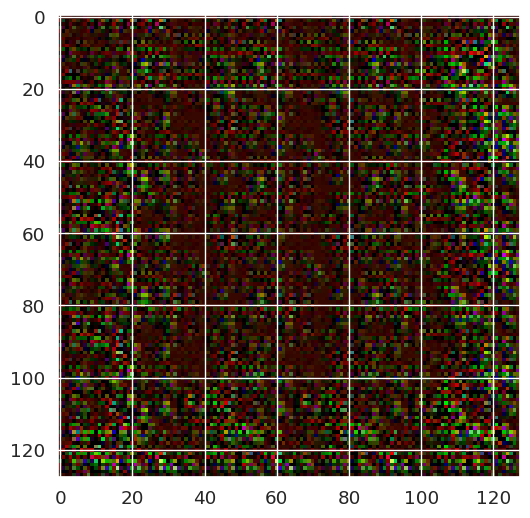

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 1
loss_d: 5.8723726654052735 loss_g: 0.06378676299192011 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296)]
score_real: 0.34298440933227536 score_fake: 0.9822518014907837


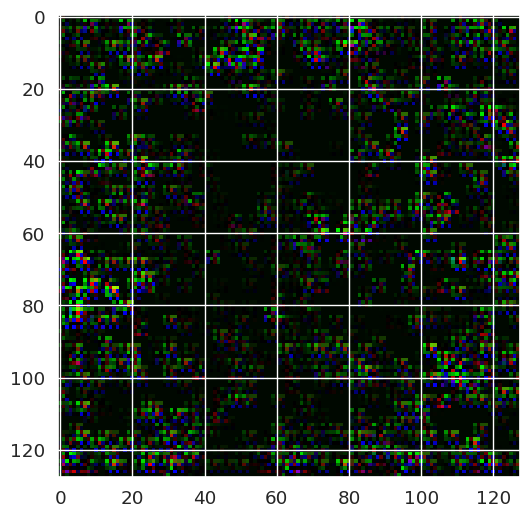

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 2
loss_d: 4.688551692962647 loss_g: 0.11443819350749254 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888)]
score_real: 0.3863872277736664 score_fake: 0.9581272506713867


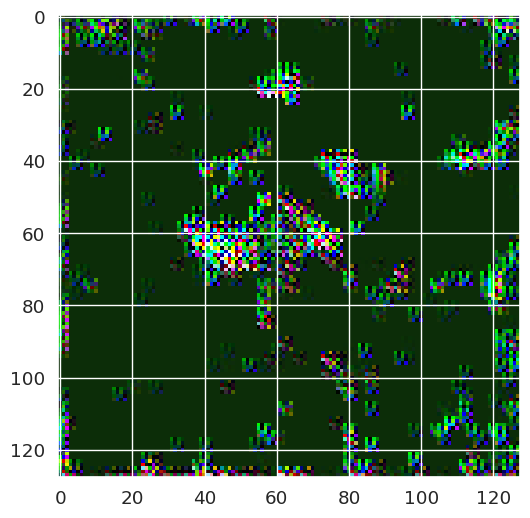

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 3
loss_d: 3.933473300933838 loss_g: 0.2084939179420471 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381)]
score_real: 0.4451305890083313 score_fake: 0.939448983669281


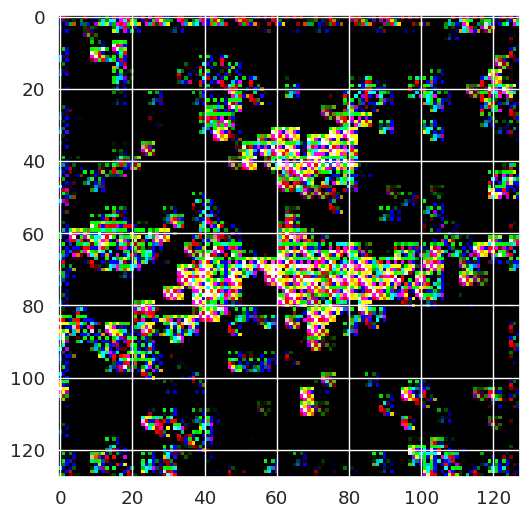

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 4
loss_d: 3.273885712623596 loss_g: 0.6010851855278015 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199)]
score_real: 0.32884033203125 score_fake: 0.791778450012207


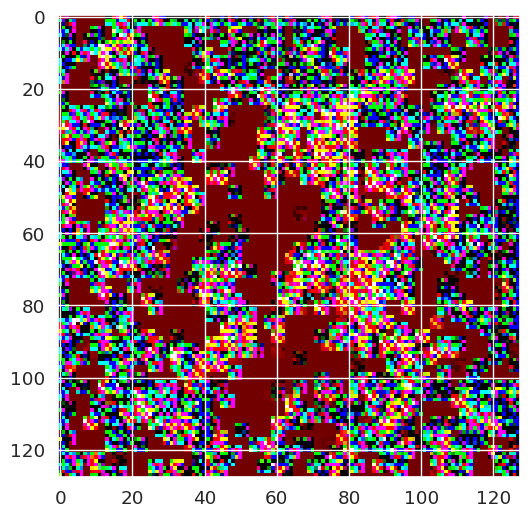

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 5
loss_d: 1.5538932299613952 loss_g: 1.2884795873165131 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275)]
score_real: 0.5063127875328064 score_fake: 0.45882154822349547


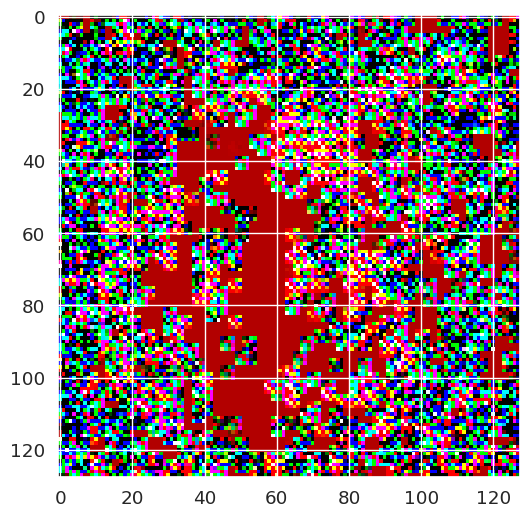

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 6
loss_d: 0.7619772267341614 loss_g: 1.7204251594543456 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437)]
score_real: 0.6958589577674865 score_fake: 0.26063504815101624


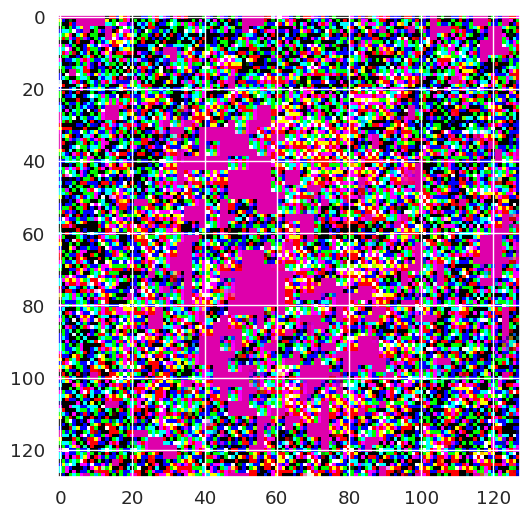

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 7
loss_d: 0.37695679783821107 loss_g: 2.1783157291412354 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547)]
score_real: 0.8276827669143677 score_fake: 0.14278431117534637


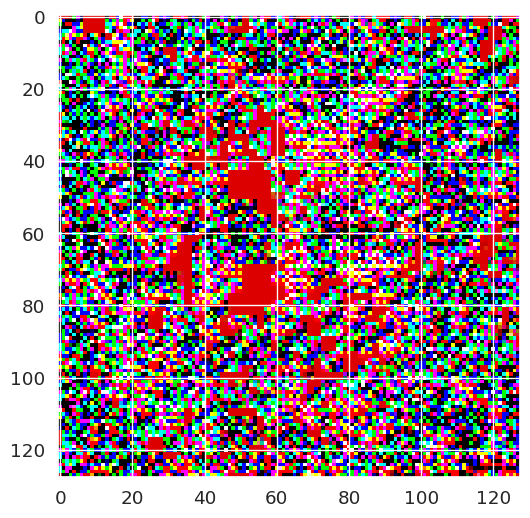

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 8
loss_d: 0.23648973762989045 loss_g: 2.524167621612549 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795)]
score_real: 0.8885665702819824 score_fake: 0.09698284059762954


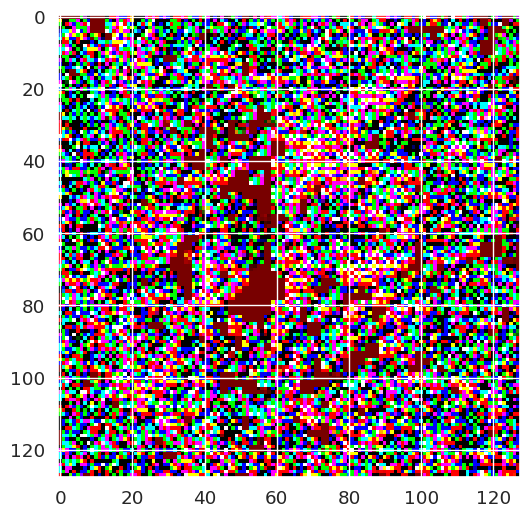

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 9
loss_d: 0.17589898854494096 loss_g: 2.7569333896636965 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795), np.float64(0.06526441699266433)]
score_real: 0.9179529523849488 score_fake: 0.07617149412631989


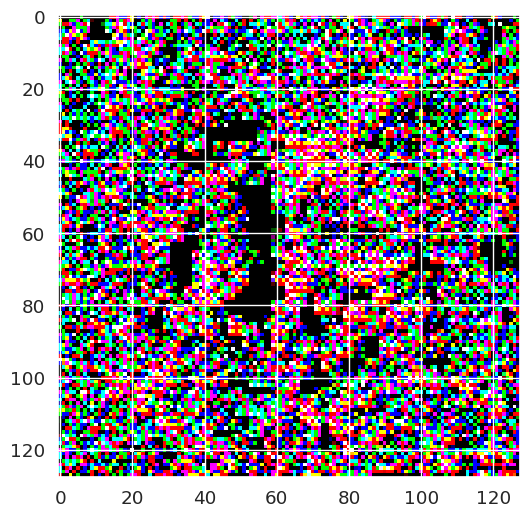

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 10
loss_d: 0.3807319498062134 loss_g: 1.5112463479042053 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795), np.float64(0.06526441699266433), np.float64(0.2565750535428524)]
score_real: 0.9322016954421997 score_fake: 0.250979543030262


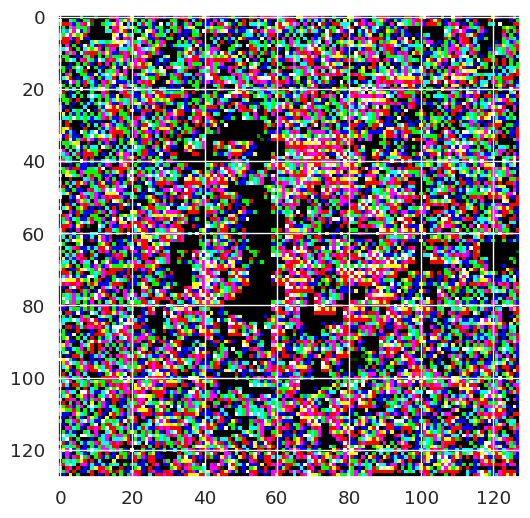

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 11
loss_d: 0.7636351895332336 loss_g: 0.704993408203125 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795), np.float64(0.06526441699266433), np.float64(0.2565750535428524), np.float64(0.49615642499923707)]
score_real: 0.93166672706604 score_fake: 0.4933362901210785


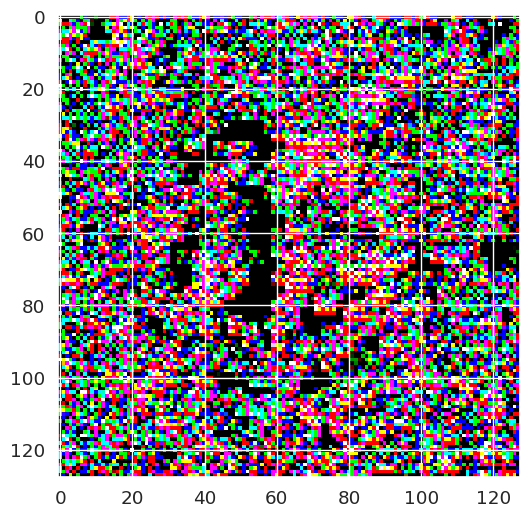

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 12
loss_d: 1.0104043292999267 loss_g: 0.5003692438602447 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795), np.float64(0.06526441699266433), np.float64(0.2565750535428524), np.float64(0.49615642499923707), np.float64(0.6066630806922912)]
score_real: 0.9317563295364379 score_fake: 0.6052527761459351


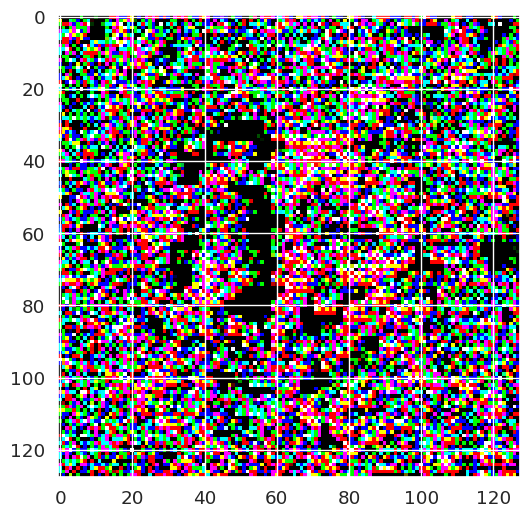

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 13
loss_d: 1.2001730871200562 loss_g: 0.3939107792377472 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795), np.float64(0.06526441699266433), np.float64(0.2565750535428524), np.float64(0.49615642499923707), np.float64(0.6066630806922912), np.float64(0.6745863423347473)]
score_real: 0.9317200851440429 score_fake: 0.6735205268859863


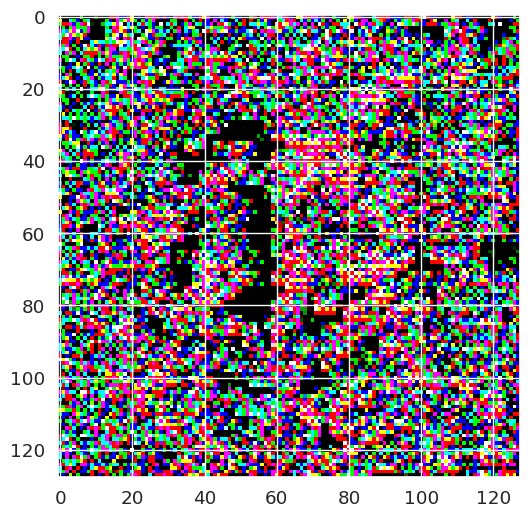

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 14
loss_d: 1.3457949781417846 loss_g: 0.3300918412208557 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795), np.float64(0.06526441699266433), np.float64(0.2565750535428524), np.float64(0.49615642499923707), np.float64(0.6066630806922912), np.float64(0.6745863423347473), np.float64(0.7189424180984497)]
score_real: 0.9321178150177002 score_fake: 0.7180103254318237


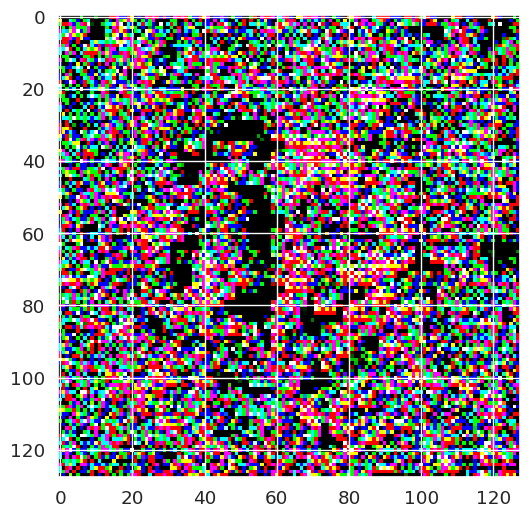

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 15
loss_d: 1.4564522647857665 loss_g: 0.29047056698799134 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795), np.float64(0.06526441699266433), np.float64(0.2565750535428524), np.float64(0.49615642499923707), np.float64(0.6066630806922912), np.float64(0.6745863423347473), np.float64(0.7189424180984497), np.float64(0.7479554314613343)]
score_real: 0.9318106341361999 score_fake: 0.7474676632881164


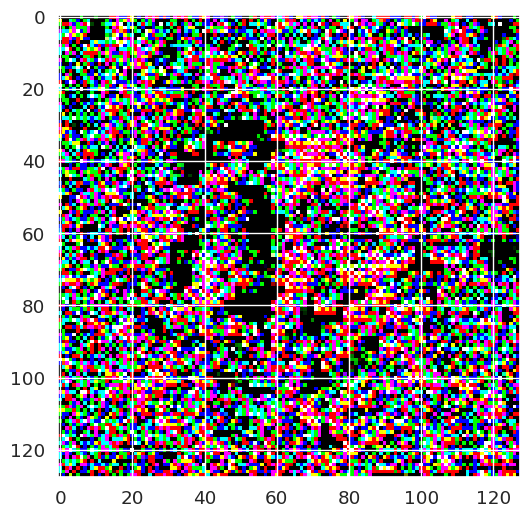

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 16
loss_d: 1.5525460624694825 loss_g: 0.2594593986272812 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795), np.float64(0.06526441699266433), np.float64(0.2565750535428524), np.float64(0.49615642499923707), np.float64(0.6066630806922912), np.float64(0.6745863423347473), np.float64(0.7189424180984497), np.float64(0.7479554314613343), np.float64(0.7715074644088745)]
score_real: 0.9317881512641907 score_fake: 0.7705994272232055


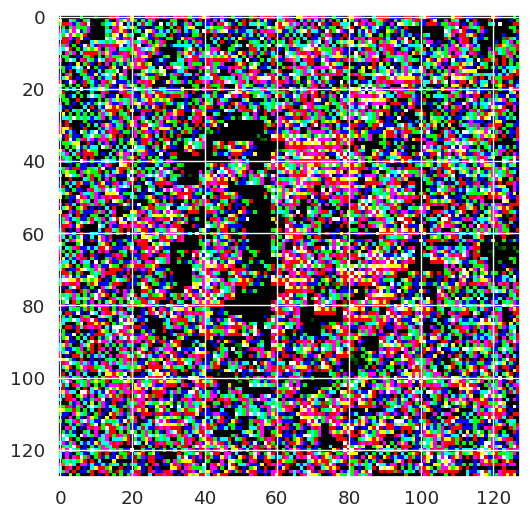

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 17
loss_d: 1.6584688234329223 loss_g: 0.23042613279819488 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795), np.float64(0.06526441699266433), np.float64(0.2565750535428524), np.float64(0.49615642499923707), np.float64(0.6066630806922912), np.float64(0.6745863423347473), np.float64(0.7189424180984497), np.float64(0.7479554314613343), np.float64(0.7715074644088745), np.float64(0.7942066841125488)]
score_real: 0.9317114210128784 score_fake: 0.7937351655960083


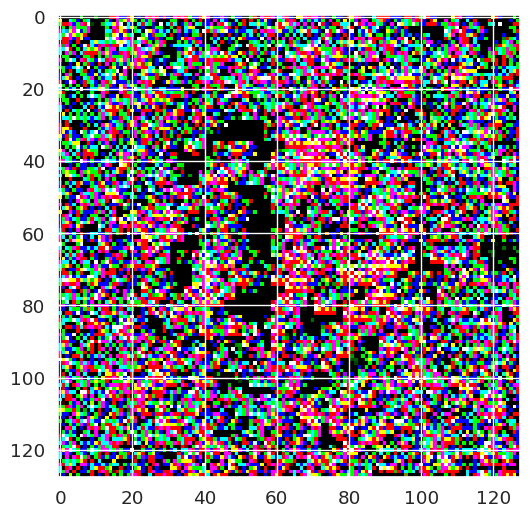

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 18
loss_d: 1.7363787174224854 loss_g: 0.2114461761713028 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795), np.float64(0.06526441699266433), np.float64(0.2565750535428524), np.float64(0.49615642499923707), np.float64(0.6066630806922912), np.float64(0.6745863423347473), np.float64(0.7189424180984497), np.float64(0.7479554314613343), np.float64(0.7715074644088745), np.float64(0.7942066841125488), np.float64(0.8094314613342285)]
score_real: 0.9317010855674743 score_fake: 0.8090584516525269


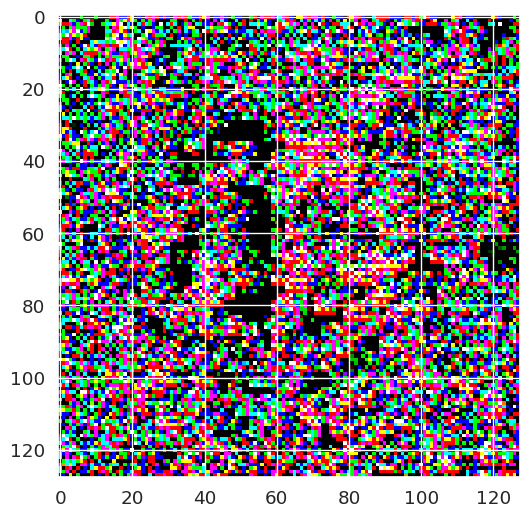

  0%|          | 0/25 [00:00<?, ?it/s]

epoch: 19
loss_d: 1.818252501487732 loss_g: 0.19264961111545562 score_gen: [np.float64(0.9690354180335998), np.float64(0.9533695811629296), np.float64(0.8988334157466888), np.float64(0.8190323476791381), np.float64(0.5979800660610199), np.float64(0.29175441253185275), np.float64(0.18448709672689437), np.float64(0.11506354695558547), np.float64(0.08217154479026795), np.float64(0.06526441699266433), np.float64(0.2565750535428524), np.float64(0.49615642499923707), np.float64(0.6066630806922912), np.float64(0.6745863423347473), np.float64(0.7189424180984497), np.float64(0.7479554314613343), np.float64(0.7715074644088745), np.float64(0.7942066841125488), np.float64(0.8094314613342285), np.float64(0.8247850484848023)]
score_real: 0.9315213704109192 score_fake: 0.8241156625747681


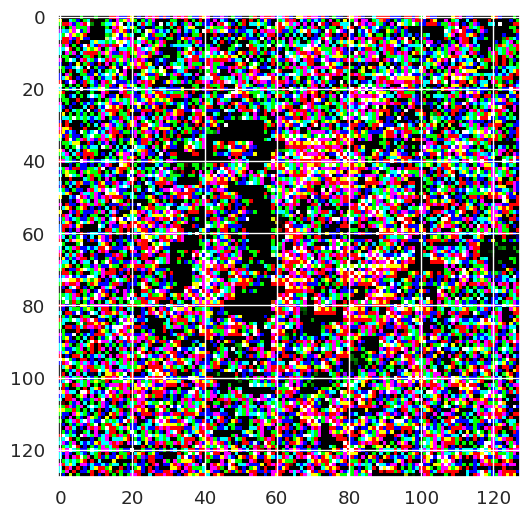

  0%|          | 0/25 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
epochs = 40
loss_d, loss_g, score_real, score_fake = fit(model=model, criterion=criterion, epochs=epochs, optimizer=optimizer)

Text(0, 0.5, 'loss')

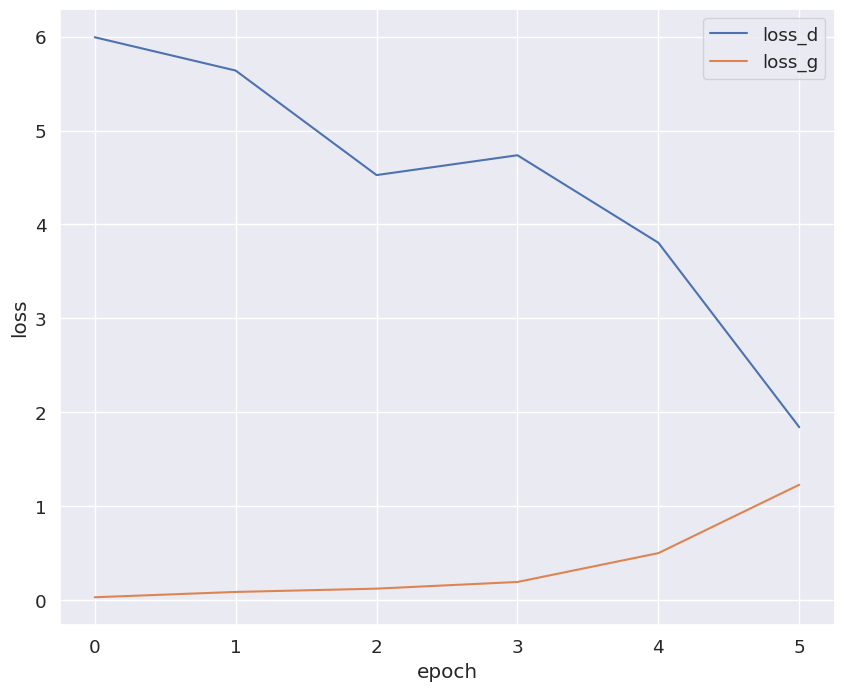

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(loss_d, '-')
plt.plot(loss_g, '-')
plt.legend(['loss_d', 'loss_g'])
plt.xlabel('epoch')
plt.ylabel('loss')


Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [ ]:
n_images = 4

fixed_latent = torch.randn(n_images, latent_size, 1, 1, device=device)
fake_images = model["generator"](fixed_latent).detach().permute(0,2,3,1).cpu().numpy()

NameError: name 'latent_size' is not defined

In [ ]:
axes.reshape(1,-1)[0]

In [ ]:
def show_images(generated):
  fig, axes = plt.subplots(2,2,figsize=(12,12))
  axes = axes.reshape(1,-1)[0]
  for i, ax in enumerate(axes):
    ax.imshow(generated[i])



In [ ]:
show_images(fake_images)

Как вам качество получившихся изображений?

## Часть 4. Leave-one-out-1-NN classifier accuracy (2.5 баллов)

### 4.1. Подсчет accuracy (1.5 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

### 4.2. Визуализация распределений (1 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

Прокомментируйте получившийся результат: